<!-- config-banner -->
# DINO 1° Tapenade adjoint — 5 yr from the 180 yr pickup

**`visc2x`** — 5 yr (1830 d) MPI adjoint from the 180 yr pickup (`nIter0=3162240`); `viscAhDfile` = `viscAhZfile` = `dino_viscAhD_2p00.bin`, **2× reference**, via `PARM05`. Run 28486.


## Loading the Data

In [62]:
from pathlib import Path
import os
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter

import warnings; warnings.filterwarnings("ignore")

In [63]:
mpl.rcParams['animation.embed_limit'] = 50  # MB (increase as needed)

In [64]:
## analyze a sample run directory (here 10 years adjoint)

run_dir = (
    "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/"
    "DINO_1deg_tapAdj_5yr_from180yrPk_visc2x_run28486/"
)
run_dir

'/scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_5yr_from180yrPk_visc2x_run28486/'

In [65]:
adxx_vars = {
    # 3D controls
    'adxx_theta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_theta',
            'long_name': 'Sensitivity to Initial Potential Temperature',
            'units': 'dJ/degC'
        }
    },

    'adxx_salt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_salt',
            'long_name': 'Sensitivity to Initial Salinity',
            'units': 'dJ/(g/kg)'
        }
    },

    'adxx_diffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_diffkr',
            'long_name': 'Sensitivity to Vertical Diffusivity',
            'units': 'dJ/(m^2/s)'
        }
    },

    # 2D time-dependent controls

    'adxx_qnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qnet',
            'long_name': 'Sensitivity to Net Surface Heat Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'adxx_qsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qsw',
            'long_name': 'Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'adxx_empmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_empmr',
            'long_name': 'Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(kg/m^2/s)'
        }
    },

    'adxx_fu': {
        'dims': ['j', 'i_g'],
        'attrs': {
            'standard_name': 'adxx_fu',
            'long_name': 'Sensitivity to Zonal Momentum Forcing',
            'units': 'dJ/(m/s^2)'
        }
    },

    'adxx_fv': {
        'dims': ['j_g', 'i'],
        'attrs': {
            'standard_name': 'adxx_fv',
            'long_name': 'Sensitivity to Meridional Momentum Forcing',
            'units': 'dJ/(m/s^2)'
        }
    }
}

In [66]:
adj_vars = {
    # 3D adjoint variables
    'ADJtheta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJtheta',
            'long_name': 'Adjoint Sensitivity to Potential Temperature',
            'units': 'dJ/degC'
        }
    },

    'ADJsalt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJsalt',
            'long_name': 'Adjoint Sensitivity to Salinity',
            'units': 'dJ/(g/kg)'
        }
    },

    'ADJdiffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJdiffkr',
            'long_name': 'Adjoint Sensitivity to Vertical Diffusivity',
            'units': 'dJ/(m^2/s)'
        }
    },

    # 2D surface momentum adjoint
    'ADJtaux': {
        'dims': ['j', 'i_g'],
        'attrs': {
            'standard_name': 'ADJtaux',
            'long_name': 'Adjoint Sensitivity to Zonal Surface Wind Stress',
            'units': 'dJ/(N/m^2)'
        }
    },

    'ADJtauy': {
        'dims': ['j_g', 'i'],
        'attrs': {
            'standard_name': 'ADJtauy',
            'long_name': 'Adjoint Sensitivity to Meridional Surface Wind Stress',
            'units': 'dJ/(N/m^2)'
        }
    },

    # 2D surface flux adjoints
    'ADJqnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqnet',
            'long_name': 'Adjoint Sensitivity to Net Surface Heat Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'ADJqsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqsw',
            'long_name': 'Adjoint Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'ADJempmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJempmr',
            'long_name': 'Adjoint Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(kg/m^2/s)'
        }
    }
}

In [67]:
adxx_prefix = ['adxx_theta','adxx_salt','adxx_diffkr','adxx_fu','adxx_fv','adxx_qnet','adxx_qsw','adxx_empmr']

adj_prefix = ['ADJtheta','ADJsalt','ADJdiffkr','ADJtaux','ADJtauy', 'ADJqnet','ADJqsw','ADJempmr']

In [68]:
ds_adxx = xmitgcm.open_mdsdataset(
    run_dir,
    grid_dir=run_dir,
    prefix=adxx_prefix,
    ref_date=np.datetime64("2000-01-01T00:00:00"),
    delta_t=1800,
    extra_variables=adxx_vars
)         

In [69]:
ds_adj = xmitgcm.open_mdsdataset(
    run_dir,
    grid_dir=run_dir,
    prefix=adj_prefix,
    ref_date=np.datetime64("2000-01-01T00:00:00"),
    delta_t=1800,
    extra_variables=adj_vars
)

In [70]:
ds_adxx

<xarray.Dataset>
Dimensions:      (time: 1, XC: 51, YC: 198, XG: 51, YG: 198, Z: 36, Zp1: 37,
                  Zu: 36, Zl: 36)
Coordinates: (12/37)
    iter         (time) int64 0
  * time         (time) datetime64[ns] 2000-01-01
  * XC           (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC           (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG           (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG           (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.97 69.33 69.68
    ...           ...
    maskCtrlW    (Z, YC, XG) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    maskCtrlS    (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF          (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF          (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV          (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU          (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    adxx_empmr   (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_diffkr  (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_qnet    (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_qsw     (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_fu      (time, YC, XG) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_salt    (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_theta   (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_fv      (time, YG, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [71]:
ds_adj

<xarray.Dataset>
Dimensions:    (time: 366, YC: 198, XC: 51, Z: 36, XG: 51, YG: 198, Zp1: 37,
                Zu: 36, Zl: 36)
Coordinates: (12/37)
    iter       (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
  * time       (time) datetime64[ns] 2180-05-16 2180-05-21 ... 2185-05-15
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG         (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG         (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.61 68.97 69.33 69.68
    ...         ...
    maskCtrlW  (Z, YC, XG) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    maskCtrlS  (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV        (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU        (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    ADJqsw     (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJdiffkr  (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJqnet    (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJempmr   (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJtaux    (time, YC, XG) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJtheta   (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtauy    (time, YG, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJsalt    (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [72]:
ds_adj.Z.values

array([   -5.0695,   -15.366 ,   -26.011 ,   -37.0775,   -48.653 ,
         -60.8435,   -73.777 ,   -87.608 ,  -102.5225,  -118.744 ,
        -136.541 ,  -156.2365,  -178.2185,  -202.9505,  -230.986 ,
        -262.985 ,  -299.7305,  -342.1485,  -391.3295,  -448.5495,
        -515.2915,  -593.2665,  -684.429 ,  -790.9845,  -915.389 ,
       -1058.674 , -1220.384 , -1402.2255, -1608.4015, -1843.9865,
       -2115.1055, -2429.1484, -2795.0244, -3223.4675, -3727.3984,
       -4300.    ], dtype=float32)

In [73]:
ds_adj.Z.values[14]

-230.986

In [74]:
ds_adxx.adxx_diffkr.shape, ds_adxx.adxx_diffkr.dims

((1, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [75]:
ds_adj.ADJdiffkr.shape, ds_adj.ADJdiffkr.dims

((366, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [76]:
ds_adj.ADJtaux.shape, ds_adj.ADJtaux.dims

((366, 198, 51), ('time', 'YC', 'XG'))

In [77]:
def print_smart_summary(ds, var):
    if var not in ds:
        print(f"{var:15s}: NOT FOUND")
        return

    arr = ds[var].values
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        print(f"{var:15s}: ALL NaN")
        return

    vmin = arr.min()
    vmax = arr.max()
    p1, p99 = np.percentile(arr, [1, 99])

    print(f"{var:15s}: "
          f"min={vmin: .2e}, max={vmax: .2e}, "
          f"p1={p1: .2e}, p99={p99: .2e}")

In [78]:
print("\n=== adxx variables ===")
for var in adxx_prefix:
    print_smart_summary(ds_adxx, var)


=== adxx variables ===
adxx_theta     : min=-8.91e-04, max= 8.74e-04, p1=-1.58e-04, p99= 1.15e-04
adxx_salt      : min=-3.93e-03, max= 3.36e-03, p1=-5.05e-04, p99= 6.99e-04
adxx_diffkr    : min=-3.72e+01, max= 3.43e+01, p1=-3.70e-01, p99= 4.35e-01
adxx_fu        : min=-2.32e-02, max= 2.67e-02, p1=-8.04e-03, p99= 9.67e-03
adxx_fv        : min=-2.23e+03, max= 5.89e+03, p1=-5.85e+02, p99= 9.39e+02
adxx_qnet      : min=-2.96e-02, max= 6.20e-02, p1=-8.27e-03, p99= 1.00e-02
adxx_qsw       : min=-3.53e-06, max= 2.75e-06, p1=-6.87e-07, p99= 1.74e-06
adxx_empmr     : min=-1.18e+04, max= 5.29e+04, p1=-3.50e+03, p99= 7.20e+03


In [79]:
print("=== ADJ variables ===")
for var in adj_prefix:
    print_smart_summary(ds_adj, var)

=== ADJ variables ===
ADJtheta       : min=-3.60e-02, max= 3.38e-02, p1=-1.98e-04, p99= 1.58e-04
ADJsalt        : min=-1.86e-01, max= 1.65e-01, p1=-7.11e-04, p99= 8.76e-04
ADJdiffkr      : min=-3.72e+01, max= 4.02e+01, p1=-1.76e-01, p99= 2.41e-01
ADJtaux        : min=-6.92e-05, max= 1.95e-05, p1=-4.87e-07, p99= 5.11e-07
ADJtauy        : min=-3.87e-02, max= 9.31e-02, p1=-7.12e-03, p99= 1.23e-02
ADJqnet        : min=-5.87e-07, max= 9.10e-07, p1=-1.76e-07, p99= 1.55e-07
ADJqsw         : min=-4.40e-10, max= 5.00e-10, p1=-2.69e-11, p99= 3.23e-11
ADJempmr       : min=-2.68e-01, max= 8.84e-01, p1=-7.65e-02, p99= 1.08e-01


## Ploting the adxx Fields

In [80]:
# ds_adxx.hFacC.isel(Z=11).plot(cmap='viridis')

In [81]:
da = ds_adxx.adxx_theta.isel(time=0, Z=11)
da

<xarray.DataArray 'adxx_theta' (YC: 198, XC: 51)>
dask.array<getitem, shape=(198, 51), dtype=>f8, chunksize=(198, 51), chunktype=numpy.ndarray>
Coordinates: (12/15)
    iter       int64 0
    time       datetime64[ns] 2000-01-01
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
    Z          >f4 -156.2
    rA         (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    ...         ...
    hFacC      (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskC      (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    rhoRef     >f4 1.026e+03
    maskCtrlC  (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Attributes:
    standard_name:  adxx_theta
    long_name:      Sensitivity to Initial Potential Temperature
    units:          dJ/degC

In [82]:
da = da.where(ds_adxx.hFacC.isel(Z=11) > 0)
da

<xarray.DataArray 'adxx_theta' (YC: 198, XC: 51)>
dask.array<where, shape=(198, 51), dtype=float64, chunksize=(198, 51), chunktype=numpy.ndarray>
Coordinates: (12/15)
    iter       int64 0
    time       datetime64[ns] 2000-01-01
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
    Z          >f4 -156.2
    rA         (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    ...         ...
    hFacC      (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskC      (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    rhoRef     >f4 1.026e+03
    maskCtrlC  (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Attributes:
    standard_name:  adxx_theta
    long_name:      Sensitivity to Initial Potential Temperature
    units:          dJ/degC

In [83]:
arr = da.values
arr

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan, -7.26681463e-11, -2.72692951e-10, ...,
         1.03036427e-09,  7.88296784e-10,             nan],
       [            nan, -4.21946453e-10, -7.40184389e-10, ...,
         1.44598517e-09,  9.57003865e-10,             nan],
       ...,
       [            nan, -4.22548826e-06, -4.22347862e-06, ...,
        -1.26420730e-06, -1.38021358e-06,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan]])

In [84]:
arr = arr[np.isfinite(arr)]
arr

array([-7.26681463e-11, -2.72692951e-10, -2.60749192e-10, ...,
       -1.48357762e-06, -1.26420730e-06, -1.38021358e-06])

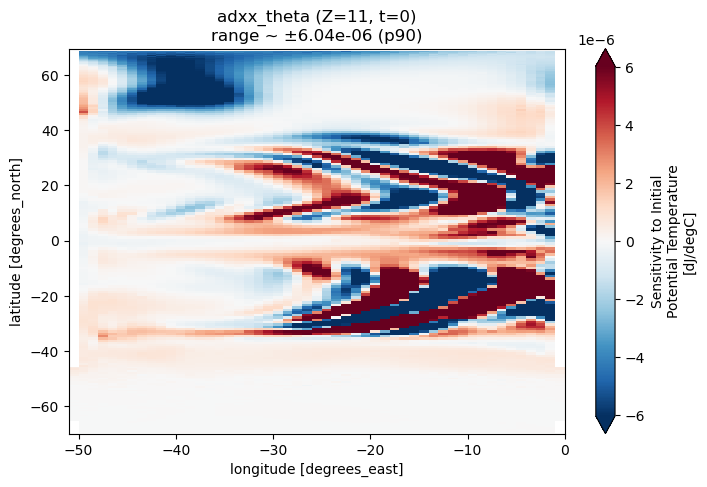

In [85]:
# Select data
t_index = 0
z_index = 11

da = ds_adxx.adxx_theta.isel(time=t_index, Z=z_index)

# Apply ocean mask
da = da.where(ds_adxx.hFacC.isel(Z=z_index) > 0) # hFacC = fraction of open water in a grid cell. 
# Values: 1 → fully ocean, 0 → land, between 0–1 → partial cell (bottom topography)

# Compute robust limits (avoid outliers)
arr = da.values # Converts your xarray.DataArray → 2D NumPy array | Drops coordinates (XC, YC, etc.), Keeps only numerical values
arr = arr[np.isfinite(arr)] # Keeps only real numbers. Removes NaN from masking. arr → 1D array of valid ocean values. arr[mask] implicitly flattens the array.

p = 90  # percentile. If you set p = 90, you are ingnoring the top 10% most extreme values
vmax = np.percentile(np.abs(arr), p) # if p = 90, This returns the value such that 90% of data is below it and 10% are larger (outliers)
vmin = -vmax

# Plot
plt.figure(figsize=(8,5))
da.plot(
    vmin=vmin,
    vmax=vmax,
    cmap='RdBu_r'
)

plt.title(f"adxx_theta (Z={z_index}, t={t_index})\n"
          f"range ~ ±{vmax:.2e} (p{p})")
plt.show()

Plotting adxx_theta


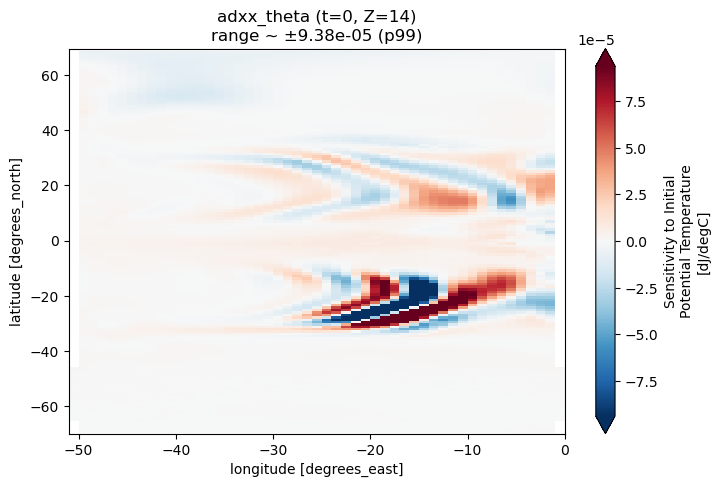

Plotting adxx_salt


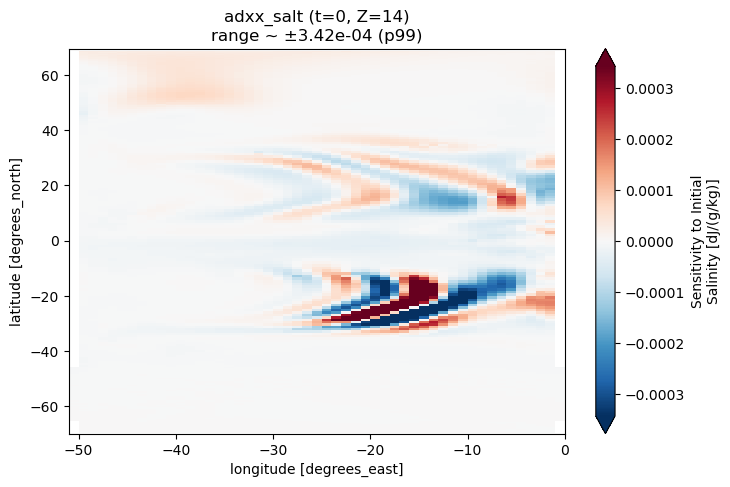

Plotting adxx_diffkr


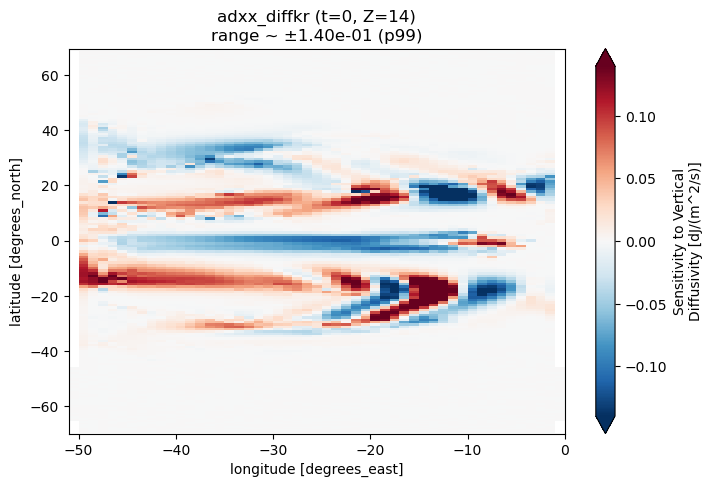

Plotting adxx_fu


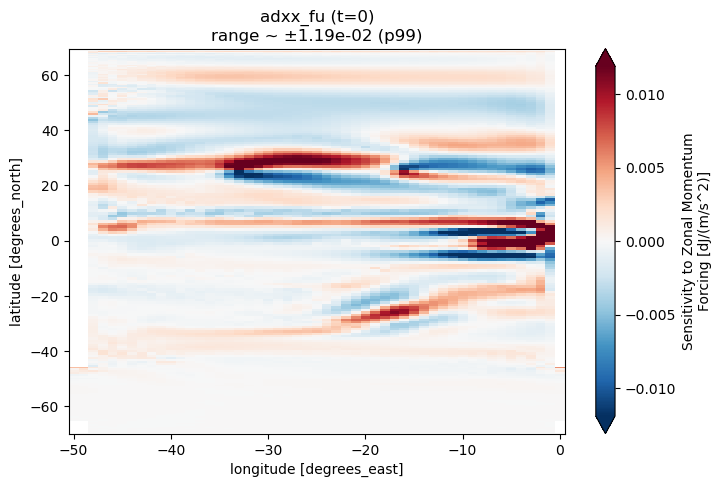

Plotting adxx_fv


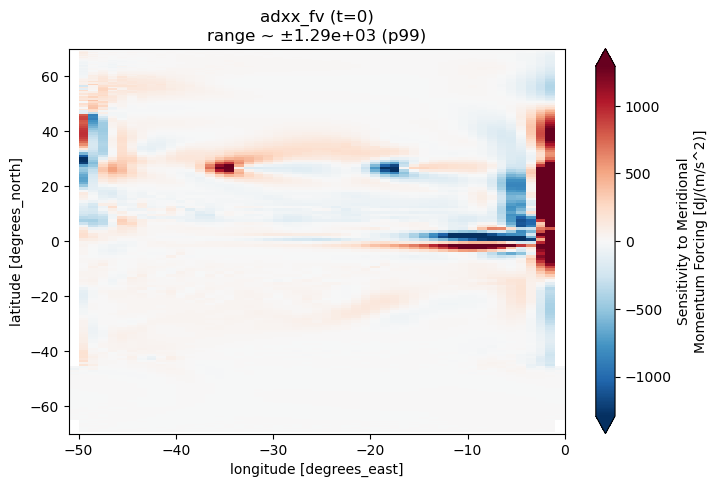

Plotting adxx_qnet


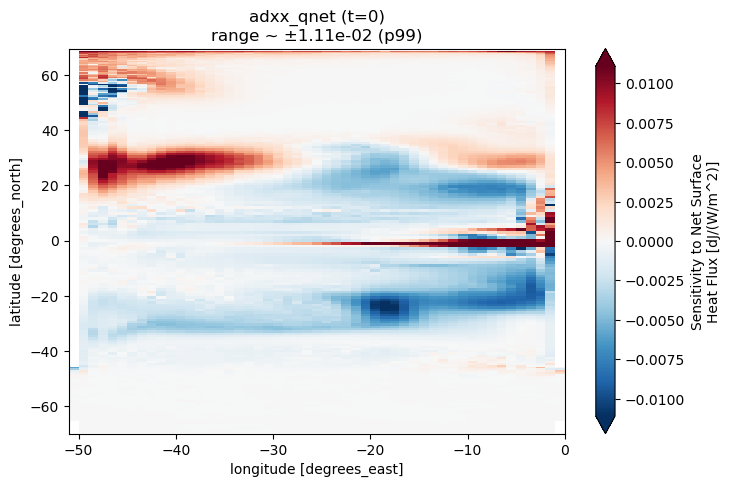

Plotting adxx_qsw


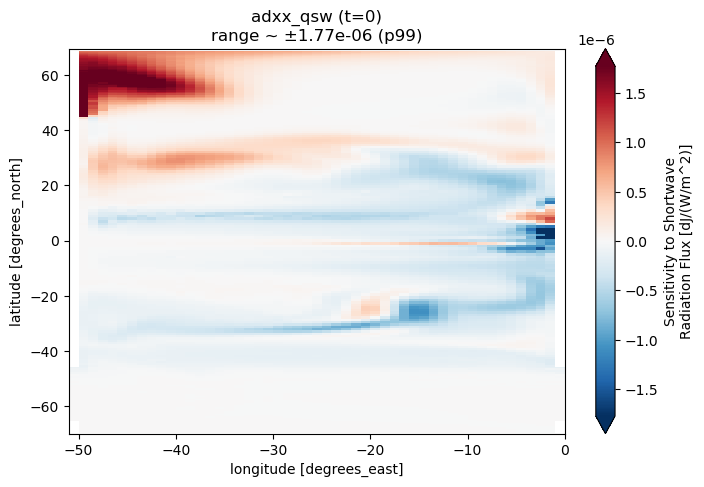

Plotting adxx_empmr


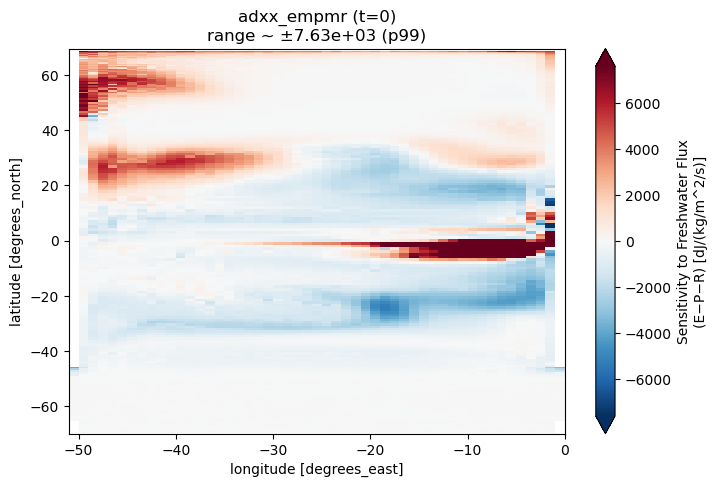

In [86]:
# --- settings ---
t_index = 0
z_index = 14
p = 99  # percentile for robust scaling

# list of variables you want
adxx_vars = [
    "adxx_theta",
    "adxx_salt",
    "adxx_diffkr",
    "adxx_fu",
    "adxx_fv",
    "adxx_qnet",
    "adxx_qsw",
    "adxx_empmr"
]

for var in adxx_vars:

    if var not in ds_adxx:
        print(f"{var} not found, skipping.")
        continue

    print(f"Plotting {var}")

    # --- select data ---
    da = ds_adxx[var]

    # Handle 3D vs 2D variables
    if 'Z' in da.dims:
        da = da.isel(time=t_index, Z=z_index)
    
        if 'XG' in da.dims:
            mask = ds_adxx.hFacW.isel(Z=z_index) > 0
        elif 'YG' in da.dims:
            mask = ds_adxx.hFacS.isel(Z=z_index) > 0
        else:
            mask = ds_adxx.hFacC.isel(Z=z_index) > 0
    
    else:
        da = da.isel(time=t_index)
    
        if 'XG' in da.dims:
            mask = ds_adxx.hFacW.isel(Z=0) > 0
        elif 'YG' in da.dims:
            mask = ds_adxx.hFacS.isel(Z=0) > 0
        else:
            mask = ds_adxx.hFacC.isel(Z=0) > 0

    # apply mask
    da = da.where(mask)

    # --- compute robust scaling ---
    arr = da.values
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        print(f"{var}: ALL NaN, skipping.")
        continue

    vmax = np.percentile(np.abs(arr), p)
    if not np.isfinite(vmax) or vmax == 0:
        vmax = np.nanmax(np.abs(arr))

    vmin = -vmax

    # --- plot ---
    plt.figure(figsize=(8,5))
    da.plot(
        vmin=vmin,
        vmax=vmax,
        cmap='RdBu_r'
    )

    plt.title(f"{var} (t={t_index}"
              + (f", Z={z_index}" if 'Z' in ds_adxx[var].dims else "")
              + f")\nrange ~ ±{vmax:.2e} (p{p})")

    plt.show()

## Animation of ADJ Fields

In [87]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [88]:
def animate_ADJ_3d(var, ds, zlev=11, interval_ms=500, p=95):
    """
    Animate 3D ADJ variable (ADJtheta, ADJsalt, ADJdiffkr)
    at a fixed depth with robust scaling.
    
    Parameters:
    - var : variable name
    - ds : dataset
    - zlev : depth index
    - interval_ms : animation speed
    - p : percentile for robust scaling (default 95)
    """

    # --- check variable ---
    if var not in ds:
        print(f"{var} not in dataset.")
        return

    if var not in ["ADJtheta", "ADJsalt", "ADJdiffkr"]:
        print(f"{var} not in selected 3D variables.")
        return

    da = ds[var].isel(Z=zlev)

    # --- apply ocean mask ---
    if 'hFacC' in ds:
        mask = ds.hFacC.isel(Z=zlev) > 0
        da = da.where(mask)

    A = da.values

    # --- robust symmetric color scale ---
    finite = np.isfinite(A)
    if finite.any():
        vmax = np.percentile(np.abs(A[finite]), p)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanmax(np.abs(A[finite]))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
    else:
        vmax = 1.0

    vmin = -vmax

    print(f"{var}: Z={zlev}, scale=±{vmax:.3e} (p{p})")

    # --- time labels ---
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # --- figure setup ---
    fig, ax = plt.subplots(figsize=(10, 5))

    pcm = da.isel(time=0).plot(
        x='XC', y='YC',
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(ds[var].attrs.get("long_name", var))
    
    depth = abs(float(ds.Z.values[zlev]))
    title = ax.set_title(f"{var} • depth={depth:.1f} m • time={tlabel(0)}")
    ax.set_xlabel("Longitude [°E]")
    ax.set_ylabel("Latitude [°N]")

    # --- update function ---
    def update(i):
        frame = da.isel(time=i).values

        # IMPORTANT: avoid NaN rendering issues
        frame = np.where(np.isfinite(frame), frame, np.nan)

        pcm.set_array(frame.ravel())
        title.set_text(f"{var} • depth={depth:.1f} m • time={tlabel(i)}")

        return pcm, title

    # reverse time (adjoint runs backward)
    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval_ms,
        blit=False
    )

    # -----------------------------------
    # save GIF
    # -----------------------------------
    out_dir = os.path.join(run_dir, "animations")
    os.makedirs(out_dir, exist_ok=True)
    gif_name = f"{out_dir}/{var}_z{zlev}.gif"
    
    anim.save(
        gif_name,
        writer="pillow",
        fps=1000 / interval_ms
    )
    
    print(f"Saved GIF: {gif_name}")
    
    # -----------------------------------
    # save interactive HTML
    # -----------------------------------
    html_name = f"{out_dir}/{var}_z{zlev}.html"
    
    html_anim = HTML(anim.to_jshtml())
    
    with open(html_name, "w") as f:
        f.write(html_anim.data)
    
    print(f"Saved interactive HTML: {html_name}")

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [89]:
animate_ADJ_3d("ADJtheta", ds_adj, zlev=14, p=96)

ADJtheta: Z=14, scale=±2.791e-05 (p96)
Saved GIF: ADJtheta_z14.gif
Saved interactive HTML: ADJtheta_z14.html


<IPython.core.display.HTML object>
[text/html animation output (22.7 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

Note about the Above Plot

I had to plot the ADJtheta file in the reverse order of the timestep. This is because, ami forward model er time step use kortesi ADJtheta file k numbering korar jonno. But adjoint runs backward in time. So jokhon plot korbo tokhon seta ke reverse timestep order e plot korte hobe.

"ADJtheta.0000000000.data" data in this file should closely corresponds to the data in the file "adxx_theta.0000000000.data"


In [90]:
def save_ADJ_3d_frames(
    var,
    ds,
    zlev=11,
    outdir=os.path.join(run_dir, "animations", "adj_frames"),
    stride=1,
    p=95,
    dpi=120,
    reverse_time=True,
    filetype="jpg"
):
    """
    Save animation frames of a 3D ADJ variable as image files.

    Parameters
    ----------
    var : str
        Variable name ("ADJtheta", "ADJsalt", "ADJdiffkr")

    ds : xarray.Dataset
        Dataset containing adjoint variables

    zlev : int
        Vertical level index

    outdir : str
        Output folder name

    stride : int
        Save every nth frame
        stride=1   -> every frame
        stride=2   -> every other frame
        stride=5   -> every 5th frame

    p : float
        Percentile for robust symmetric color scaling

    dpi : int
        Image DPI
        Lower DPI -> smaller file size

    reverse_time : bool
        Reverse time order for adjoint visualization

    filetype : str
        "jpg" (recommended for small PDFs)
        or "png"
    """

    # -----------------------------
    # Check variable
    # -----------------------------
    if var not in ds:
        print(f"{var} not found in dataset.")
        return

    da = ds[var].isel(Z=zlev)

    # -----------------------------
    # Ocean mask
    # -----------------------------
    if "hFacC" in ds:
        mask = ds.hFacC.isel(Z=zlev) > 0
        da = da.where(mask)

    # -----------------------------
    # Robust color scale
    # -----------------------------
    A = da.values
    finite = np.isfinite(A)

    if finite.any():
        vmax = np.percentile(np.abs(A[finite]), p)

        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanmax(np.abs(A[finite]))

        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
    else:
        vmax = 1.0

    vmin = -vmax

    # -----------------------------
    # Depth label
    # -----------------------------
    depth = abs(float(ds.Z.values[zlev]))

    # -----------------------------
    # Time indices
    # -----------------------------
    nt = da.sizes["time"]

    frames = np.arange(0, nt, stride)

    if reverse_time:
        frames = frames[::-1]

    # -----------------------------
    # Create output directory
    # -----------------------------
    os.makedirs(outdir, exist_ok=True)

    print(f"Saving {len(frames)} frames to: {outdir}")
    print(f"Depth = {depth:.1f} m")
    print(f"Color scale = ±{vmax:.3e}")

    # -----------------------------
    # Save frames
    # -----------------------------
    for n, i in enumerate(frames):

        fig, ax = plt.subplots(figsize=(10, 5))

        da.isel(time=i).plot(
            x="XC",
            y="YC",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            add_colorbar=True,
            ax=ax
        )

        # Time label
        try:
            tstr = np.datetime_as_string(
                da.time.values[i],
                unit="D"
            )
        except Exception:
            tstr = str(da.time.values[i])

        ax.set_title(
            f"{var} • depth={depth:.1f} m • time={tstr}"
        )

        ax.set_xlabel("Longitude [°E]")
        ax.set_ylabel("Latitude [°N]")

        fname = os.path.join(
            outdir,
            f"{var}_{n:04d}.{filetype}"
        )

        plt.savefig(
            fname,
            dpi=dpi,
            bbox_inches="tight"
        )

        plt.close(fig)

    print("Done.")

In [91]:
save_ADJ_3d_frames(
    "ADJtheta",
    ds_adj,
    zlev=14,
    outdir=os.path.join(run_dir, "animations", "adj_theta_z14"),
    stride=4,
    p=96,
    dpi=100,
    filetype="jpg"
)

Saving 92 frames to: adj_theta_z14
Depth = 231.0 m
Color scale = ±2.791e-05
Done.


In [94]:
animate_ADJ_3d("ADJsalt", ds_adj, zlev=14, p=96)

ADJsalt: Z=14, scale=±1.054e-04 (p96)
Saved GIF: ADJsalt_z14.gif
Saved interactive HTML: ADJsalt_z14.html


<IPython.core.display.HTML object>
[text/html animation output (27.2 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [95]:
animate_ADJ_3d("ADJdiffkr", ds_adj, zlev=14, p=96)

ADJdiffkr: Z=14, scale=±5.097e-02 (p96)
Saved GIF: ADJdiffkr_z14.gif
Saved interactive HTML: ADJdiffkr_z14.html


<IPython.core.display.HTML object>
[text/html animation output (21.8 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [96]:
def animate_ADJ_2d(var, ds, mask_level=0, interval_ms=500, p=95):
    """
    Animate a 2D ADJ field over time.
    Works for XC/YC, XG/YC, XC/YG (all staggered grids).

    Parameters:
    - p : percentile for robust scaling (default 95)
    """

    if var not in ds:
        print(f"{var} not found in dataset.")
        return

    da = ds[var]

    # Apply mask only for tracer grid
    if 'hFacC' in ds and 'XC' in da.dims and 'YC' in da.dims:
        mask = ds.hFacC.isel(Z=mask_level) > 0
        da = da.where(mask)

    A = da.values

    # robust symmetric color scale (UPDATED)
    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), p)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0

    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, scale=±{v:.3e} (p{p})")

    # time helper
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # grid-aware
    xcoord = 'XC' if 'XC' in da.dims else 'XG'
    ycoord = 'YC' if 'YC' in da.dims else 'YG'

    # --- figure ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # initial plot
    pcm = da.isel(time=0).plot(
        x=xcoord, y=ycoord,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(da.attrs.get('long_name', var))

    title = ax.set_title(f"{var} • time={tlabel(0)}")

    # update
    def update(i):
        ax.clear()

        da.isel(time=i).plot(
            x=xcoord, y=ycoord,
            cmap='RdBu_r',
            vmin=vmin, vmax=vmax,
            add_colorbar=False,
            ax=ax
        )

        ax.set_title(f"{var} • time={tlabel(i)}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        return ax,

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval_ms, blit=False)

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [97]:
animate_ADJ_2d("ADJtaux", ds_adj, p=96)

ADJtaux: shape=(366, 198, 51), scale=±3.138e-07 (p96)


<IPython.core.display.HTML object>
[text/html animation output (25.5 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [98]:
animate_ADJ_2d("ADJtauy", ds_adj, p=96)

ADJtauy: shape=(366, 198, 51), scale=±5.248e-03 (p96)


<IPython.core.display.HTML object>
[text/html animation output (25.2 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [99]:
animate_ADJ_2d("ADJqnet", ds_adj, p=96)

ADJqnet: shape=(366, 198, 51), scale=±1.201e-07 (p96)


<IPython.core.display.HTML object>
[text/html animation output (23.2 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [100]:
animate_ADJ_2d("ADJqsw", ds_adj, p=96)

ADJqsw: shape=(366, 198, 51), scale=±2.103e-11 (p96)


<IPython.core.display.HTML object>
[text/html animation output (24.6 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [101]:
animate_ADJ_2d("ADJempmr", ds_adj, p=96)

ADJempmr: shape=(366, 198, 51), scale=±6.738e-02 (p96)


<IPython.core.display.HTML object>
[text/html animation output (24.6 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]